In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = 'https://aplicacoes.mds.gov.br/sagi/servicos/equipamentos?fq=tipo_equipamento:POSTO_CADASTRAMENTO&wt=csv&fl=id_equipamento,ibge,uf,cidade,nome,responsavel,telefone,endereco,numero,complemento,referencia,bairro,cep,georef_location,data_atualizacao&rows=999999999&q=*:*'

In [3]:
df = pd.read_csv(url)

In [4]:
df.head()

,id_equipamento,ibge,uf,cidade,nome,responsavel,telefone,endereco,numero,complemento,referencia,bairro,cep,georef_location,data_atualizacao
0,485792,230320,CE,CARIRIAÇU,POSTO CADASTRO ÚNICO CARIRIAÇU,NaN,NaN,MIGUEL XAVIER 0,0,NaN,NaN,MESTRE NECO,63220000,"-7.041864440458923\,-39.280283450352734",2026-10-02T04:58:07.018Z
1,485764,420775,SC,IRACEMINHA,Cadastro Único,NaN,NaN,Dona Paulina 780,780,casa,NaN,centro,89891000,"-26.82541118487545\,-53.27285528182984",2026-10-02T04:58:07.096Z
2,485738,231020,CE,PARACURU,CadÚnico Paracuru,NaN,NaN,Coronel Meireles 645,645,NaN,NaN,Centro,62680000,"-3.4153298674319985\,-39.028699994087226",2026-10-02T04:58:07.096Z
3,485962,292593,BA,QUIXABEIRA,Cadastro Único - Quixabeira,NaN,NaN,CRUZEIRO DO SUL 190,190,NaN,NaN,CENTRO,44713000,"-11.412\,-40.128",2026-10-02T04:58:07.096Z
4,489298,431057,RS,ITAPUCA,Setor de Cadastro Único,NaN,NaN,ARVOREZINHA 904,904,NaN,NaN,CENTRO,95997000,"-28.779569436263216\,-52.17321932315827",2026-10-02T04:58:07.166Z


In [5]:
df['data_atualizacao'].unique()

<ArrowStringArray>
['2026-10-02T04:58:07.018Z', '2026-10-02T04:58:07.096Z',
 '2026-10-02T04:58:07.166Z', '2026-10-02T04:58:07.250Z',
 '2026-10-02T04:58:07.324Z', '2026-10-02T04:58:07.402Z',
 '2026-10-02T04:58:07.484Z', '2026-10-02T04:58:07.565Z',
 '2026-10-02T04:58:06.620Z', '2026-10-02T04:58:06.705Z',
 '2026-10-02T04:58:06.784Z', '2026-10-02T04:58:06.856Z',
 '2026-10-02T04:58:06.932Z', '2026-10-02T04:58:07.659Z',
 '2026-10-02T04:58:07.751Z', '2026-10-02T04:58:07.849Z',
 '2026-10-02T04:58:07.941Z', '2026-10-02T04:58:08.033Z',
 '2026-10-02T04:58:08.123Z', '2026-10-02T04:58:08.211Z']
Length: 20, dtype: str

In [6]:
df = (
    df[['uf', 'cidade', 'ibge']]
    .rename(columns={
        'uf': 'sigla_uf'
    })
)

In [7]:
df.isna().sum()

sigla_uf    1
cidade      5
ibge        0
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.isna().sum()

sigla_uf    0
cidade      0
ibge        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(397)

In [11]:
df.dtypes

sigla_uf      str
cidade        str
ibge        int64
dtype: object

In [12]:
df.head()

,sigla_uf,cidade,ibge
0,CE,CARIRIAÇU,230320
1,SC,IRACEMINHA,420775
2,CE,PARACURU,231020
3,BA,QUIXABEIRA,292593
4,RS,ITAPUCA,431057


In [13]:
df = (
    df.groupby('sigla_uf')
    .agg({
        'ibge': 'count'
    })
    .rename(columns={
        'ibge': 'quantidade'
    })
    .sort_values('quantidade', ascending=False)
    .reset_index()
    .assign(qtde_pct = lambda x: ((x['quantidade'] / x['quantidade'].sum()) * 100).round(2))
)

In [14]:
df.head()

,sigla_uf,quantidade,qtde_pct
0,SP,482,13.57
1,BA,445,12.53
2,MG,435,12.25
3,CE,208,5.86
4,MA,207,5.83


In [47]:
df.to_latex('qtde_postos_cadunico_por_uf.tex', index=False, longtable=True)

In [41]:
df.head().to_latex('qtde_postos_cadunico_por_uf_top5.tex', index=False)

In [15]:
df.tail()

,sigla_uf,quantidade,qtde_pct
22,MS,22,0.62
23,DF,18,0.51
24,RO,13,0.37
25,AP,12,0.34
26,RR,12,0.34


In [40]:
df.tail().to_latex('qtde_postos_cadunico_por_uf_bottom5.tex', index=False)

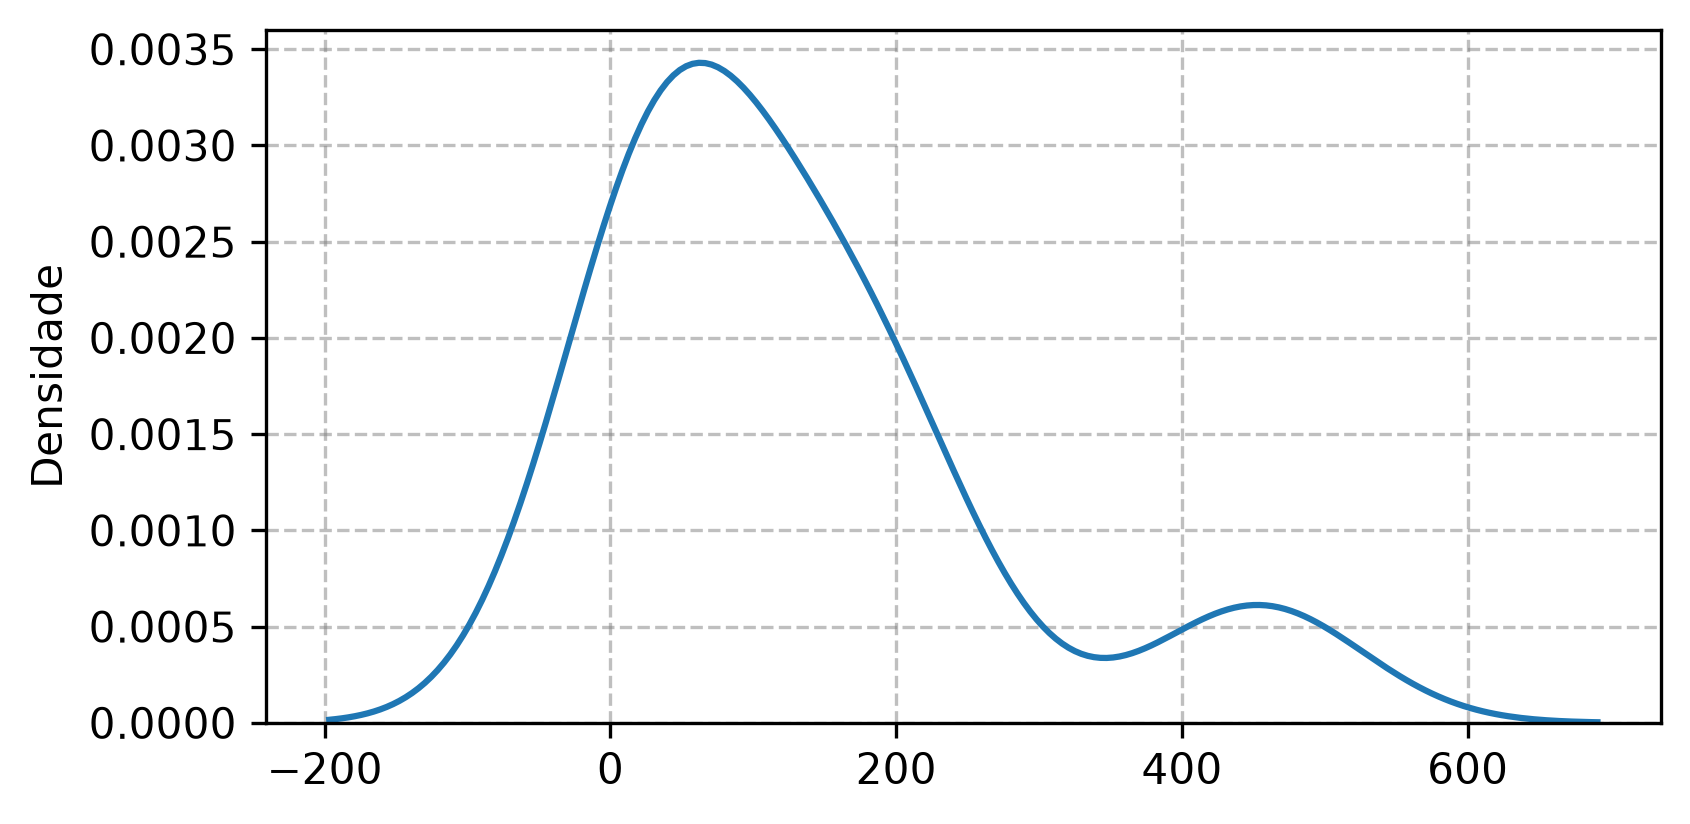

In [42]:
fig, ax = plt.subplots(
    dpi=300, 
    figsize=(6, 3),
    
)

sns.kdeplot(
    df, 
    x='quantidade'
)

ax.grid(linestyle='--', alpha=0.5, color='grey')
ax.set_ylabel('Densidade')
ax.set_xlabel('')

fig.savefig('kde_qtde_postos_cadunico_por_uf', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
df['quantidade'].skew()

np.float64(1.5292730706627358)

In [18]:
df['quantidade'].median()

np.float64(96.0)

In [20]:
df.query('quantidade.median() <= quantidade').reset_index(drop=True)

,sigla_uf,quantidade,qtde_pct
0,SP,482,13.57
1,BA,445,12.53
2,MG,435,12.25
3,CE,208,5.86
4,MA,207,5.83
5,PE,204,5.74
6,PB,195,5.49
7,RS,182,5.12
8,SC,169,4.76
9,RN,152,4.28


In [48]:
df.query('quantidade.median() <= quantidade').reset_index(drop=True).to_latex('qtde_postos_cadunico_por_uf_qtde_acima_igual_mediana.tex', index=False, longtable=True)

In [21]:
df.query('quantidade.median() >= quantidade')['sigla_uf'].count()

np.int64(14)

In [22]:
gdf_ufs = (
    gpd.read_file('../../compartilhado/BR_UF_2025')
        .drop(columns=['CD_UF', 'CD_REGIAO', 'AREA_KM2', 'SIGLA_RG'])
        .rename(columns={
            'NM_UF': 'uf',
            'SIGLA_UF': 'sigla_uf',
            'NM_REGIAO': 'regiao',
        })
        .replace({
            'Centro-oeste': 'Centro-Oeste'
        })
)

In [23]:
gdf_ufs.head()

,uf,sigla_uf,regiao,geometry
0,Rio Grande do Sul,RS,Sul,"MULTIPOLYGON (((-53.52154 -33.25881, -53.51825..."
1,São Paulo,SP,Sudeste,"MULTIPOLYGON (((-48.03575 -25.35712, -48.03607..."
2,Espírito Santo,ES,Sudeste,"MULTIPOLYGON (((-40.88385 -21.16198, -40.88384..."
3,Rio de Janeiro,RJ,Sudeste,"MULTIPOLYGON (((-44.72025 -23.35934, -44.72029..."
4,Paraná,PR,Sul,"MULTIPOLYGON (((-48.40723 -25.84254, -48.40732..."


In [24]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    ).head()
)

,uf,sigla_uf,regiao,geometry,quantidade,qtde_pct
0,Rio Grande do Sul,RS,Sul,"MULTIPOLYGON (((-53.52154 -33.25881, -53.51825...",182,5.12
1,São Paulo,SP,Sudeste,"MULTIPOLYGON (((-48.03575 -25.35712, -48.03607...",482,13.57
2,Espírito Santo,ES,Sudeste,"MULTIPOLYGON (((-40.88385 -21.16198, -40.88384...",38,1.07
3,Rio de Janeiro,RJ,Sudeste,"MULTIPOLYGON (((-44.72025 -23.35934, -44.72029...",79,2.22
4,Paraná,PR,Sul,"MULTIPOLYGON (((-48.40723 -25.84254, -48.40732...",96,2.70


In [25]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })
    .sort_values('quantidade', ascending=False)
    .reset_index()
    .assign(qtde_pct = lambda x: ((x['quantidade'] / x['quantidade'].sum()) * 100).round(2))
)

,regiao,quantidade,qtde_pct
0,Nordeste,1587,44.68
1,Sudeste,1034,29.11
2,Sul,447,12.58
3,Norte,300,8.45
4,Centro-Oeste,184,5.18


In [32]:
gdf_ufs = (
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })
    .sort_values('quantidade', ascending=False)
    .reset_index()
    .assign(qtde_pct = lambda x: ((x['quantidade'] / x['quantidade'].sum()) * 100).round(2))
)

In [ ]:
gdf_ufs.to_latex('qtde_postos_cadunico_por_regiao.tex', index=False)

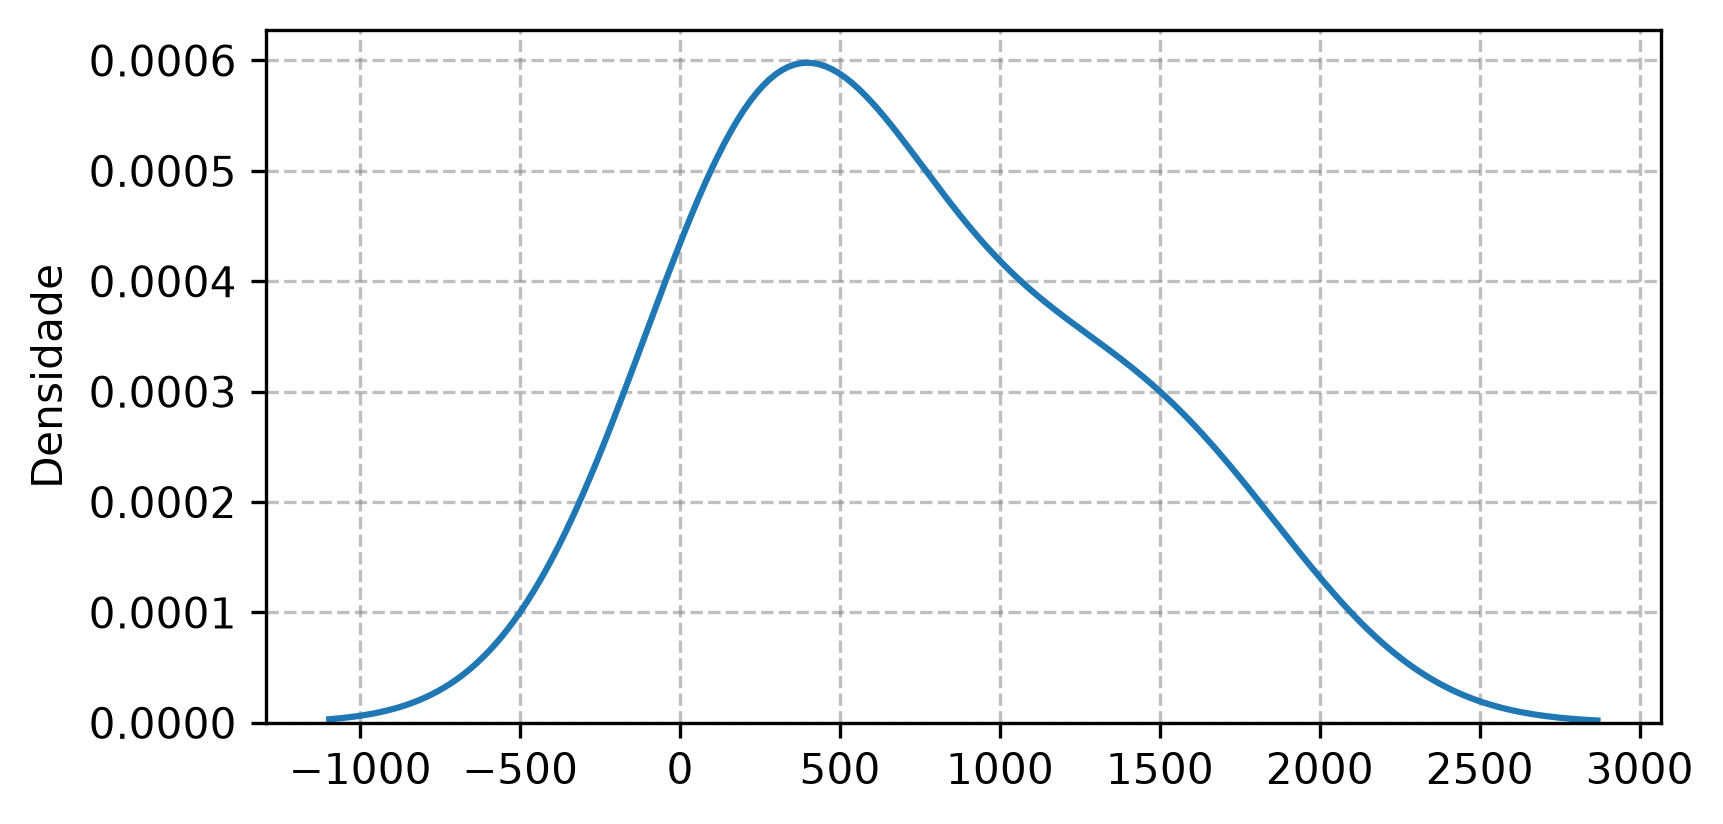

In [37]:
fig, ax = plt.subplots(
    dpi=300, 
    figsize=(6, 3),
    
)

sns.kdeplot(
    gdf_ufs, 
    x='quantidade'
)

ax.grid(linestyle='--', alpha=0.5, color='grey')
ax.set_ylabel('Densidade')
ax.set_xlabel('')

fig.savefig('kde_qtde_postos_cadunico_por_regiao', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })
    ['quantidade']
    .skew()
)


np.float64(0.9666277650279653)

In [29]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })
    ['quantidade']
    .median()
)

np.float64(447.0)

In [30]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })
    .query('quantidade.median() <= quantidade')
)

,quantidade
regiao,
Nordeste,1587
Sudeste,1034
Sul,447


In [31]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    ).to_file('qtde_postos_cadunico.gpkg', driver='GPKG')
)